
# Phase 2B-2 — Frozen Observation-Density × Forecast-Horizon Study
## Oklahoma real-ERA5 3-hour physics-informed thermal forecast

### Why this is the next meaningful step

The model has now produced three distinct pieces of evidence:

**Dense frozen chronological replication (100% temperature field)**
- PINN mean RMSE: **0.6410 K**
- strongest-baseline mean RMSE: **0.7814 K**
- improvement: **+17.97%**
- overall win rate: **75%**
- +3 h win rate: **75%**

**10% sparse-observation experiment**
- PINN mean RMSE: **0.7427 K**
- strongest-baseline mean RMSE: **0.8184 K**
- improvement: **+9.25%**
- overall win rate: **62.5%**
- +3 h win rate: **87.5%**

The 10% experiment did not satisfy every predeclared gate criterion, but it revealed a strong horizon pattern:

- +1 h: little PINN advantage,
- +2 h: moderate advantage,
- +3 h: substantially larger advantage.

The next scientific question is therefore not simply “does 10% pass?” It is:

> **How does the PINN advantage change jointly with observation density and forecast horizon?**

This notebook constructs that operating-regime map.

## Design

The successful formulation is frozen. We add only two new observation densities:

- **25% sensors**
- **5% sensors**

The already-executed:
- **100% dense replication**, and
- **10% sparse run**

are embedded as immutable reference results, so they do not need to be rerun.

The sparse sensor networks are **nested** by construction using the same deterministic farthest-point ordering:

\[
5\% \subset 10\% \subset 25\%.
\]

Therefore, changing density does not change the sensor-placement rule.

## Frozen components

No tuning is allowed:

- Oklahoma, Aug. 18–21, 2026;
- same four forecast origins;
- seeds 101 and 202;
- 12 h thermal history;
- +1/+2/+3 h forecast;
- potential-temperature target;
- same 4×64 tanh models;
- same constrained heating closure;
- same physics/data/boundary weights;
- same causal training;
- same persistence, trend, coordinate-NN, and forcing-aware-NN baselines;
- same ERA5 meteorological forcing;
- same 4° outer buffer.

## Primary Phase 2B-2 output

A **density × lead-time performance surface** using:

1. PINN RMSE;
2. strongest-baseline RMSE;
3. PINN improvement over strongest baseline;
4. PINN win rate.

This experiment is intended to identify the **operating regime** in which physics adds practical value, rather than to search for a density that happens to produce a favorable result.


In [1]:
!pip install -q "cdsapi>=0.7.7" xarray netCDF4 h5netcdf scipy pandas matplotlib torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.9 MB/s eta 0:00:00


In [2]:

import copy
import io
import math
import os
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.interpolate import RegularGridInterpolator, griddata
from scipy.ndimage import distance_transform_edt

import torch
import torch.nn as nn
from IPython.display import display

torch.set_default_dtype(torch.float32)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda



## CDS credential
This notebook deliberately does not copy a credential from an earlier notebook.


In [3]:

CDS_KEY = os.environ.get("CDSAPI_KEY", "").strip()
if not CDS_KEY:
    CDS_KEY = "PASTE_YOUR_CDS_KEY_HERE"

if CDS_KEY == "PASTE_YOUR_CDS_KEY_HERE":
    raise ValueError(
        "Paste your CDS API key into CDS_KEY (or set environment variable CDSAPI_KEY), then rerun."
    )

with open(os.path.expanduser("~/.cdsapirc"), "w") as f:
    f.write("url: https://cds.climate.copernicus.eu/api\n")
    f.write(f"key: {CDS_KEY}\n")

print("CDS credential configured.")


CDS credential configured.



## Frozen Phase-2A configuration
Leave `RUN_MODE="gate"` for the scientific run. `"smoke"` is only a runtime/debug check and must not be interpreted scientifically.


In [4]:

EVENT_START = "2026-08-18"
EVENT_END   = "2026-08-21"

# Inner evaluation domain from the Oklahoma audit.
EVAL_LAT_BOUNDS = (33.5, 37.0)
EVAL_LON_BOUNDS = (-100.0, -94.5)

# Large outer buffer. Future T is scored only in the inner domain.
BUFFER_DEG = 4.0
MODEL_LAT_BOUNDS = (EVAL_LAT_BOUNDS[0] - BUFFER_DEG, EVAL_LAT_BOUNDS[1] + BUFFER_DEG)
MODEL_LON_BOUNDS = (EVAL_LON_BOUNDS[0] - BUFFER_DEG, EVAL_LON_BOUNDS[1] + BUFFER_DEG)

PRESSURE_LEVELS_HPA = np.array([700.0, 850.0, 925.0])
P0_HPA = 1000.0

HISTORY_HOURS = 12
FORECAST_HOURS = 3
TREND_HOURS = 4

FORECAST_ORIGINS_GATE = [
    "2026-08-19 12:00:00",
    "2026-08-19 18:00:00",
    "2026-08-20 12:00:00",
    "2026-08-20 18:00:00",
]
SEEDS_GATE = [101, 202]

RUN_MODE = "gate"  # "gate" or "smoke"

# ---------------------------
# Phase 2B-1 sparse-observation gate
# ---------------------------
DENSITIES_TO_RUN = [0.25, 0.05]
SENSOR_SELECTION_SEED = 4242
MIN_SENSOR_COUNT = 25

# This gate intentionally uses one fixed spatial sensor network across all
# forecast origins and both random seeds.

if RUN_MODE == "smoke":
    FORECAST_ORIGINS = FORECAST_ORIGINS_GATE[:1]
    SEEDS = [101]
else:
    FORECAST_ORIGINS = FORECAST_ORIGINS_GATE
    SEEDS = SEEDS_GATE

SURFACE_PRESSURE_MARGIN_HPA = 20.0

HIDDEN = 64
LAYERS = 4

# Exact differentiable initial-field check.
EXACT_IC_GRID_RMSE_TOL_K = 2e-4

# Main models.
STAGE_A_STEPS = 1500
FUTURE_STAGE_STEPS = 1000
TOTAL_MAIN_STEPS = STAGE_A_STEPS + FORECAST_HOURS * FUTURE_STAGE_STEPS

DATA_BATCH = 4096
PHYS_BATCH = 2048
BOUNDARY_BATCH = 768

PAST_PHYS_POOL = 50000
FUTURE_PHYS_POOL = 50000
BOUNDARY_POOL = 15000

LEARNING_RATE = 1e-3
GRAD_CLIP = 5.0

LAMBDA_PHYSICS = 1.0
LAMBDA_BOUNDARY = 0.05
LAMBDA_SOURCE_REG = 1e-3

MAX_LATENT_SCALE = 2.0
MAX_B0_K_PER_H = 0.30
MAX_BP_K_PER_H = 0.30
MAX_DIURNAL_K_PER_H = 0.50

# Practical screening gate, not a formal statistical test.
MIN_MEAN_IMPROVEMENT_PCT = 5.0
MIN_WIN_RATE = 0.67
MIN_LEAD3_WIN_RATE = 0.50

ERA5_FILE = "era5_phase2B_oklahoma_aug18_21_pressure.nc"
SURFACE_FILE = "era5_phase2B_oklahoma_aug18_21_surface.nc"

print("Run mode:", RUN_MODE)
print("Origins:", FORECAST_ORIGINS)
print("Seeds:", SEEDS)
print("Evaluation region:", EVAL_LAT_BOUNDS, EVAL_LON_BOUNDS)
print("Buffered model region:", MODEL_LAT_BOUNDS, MODEL_LON_BOUNDS)

print("New densities to run:", DENSITIES_TO_RUN)


Run mode: gate
Origins: ['2026-08-19 12:00:00', '2026-08-19 18:00:00', '2026-08-20 12:00:00', '2026-08-20 18:00:00']
Seeds: [101, 202]
Evaluation region: (33.5, 37.0) (-100.0, -94.5)
Buffered model region: (29.5, 41.0) (-104.0, -90.5)
New densities to run: [0.25, 0.05]



## Download ERA5
ERA5 pressure-level fields used here are temperature, horizontal wind, pressure vertical velocity, and specific humidity. Surface pressure is downloaded separately for terrain screening.


In [5]:

import cdsapi

days = pd.date_range(EVENT_START, EVENT_END, freq="D")
if days.to_period("M").nunique() != 1:
    raise ValueError("The requested event must stay within one calendar month.")

area = [
    MODEL_LAT_BOUNDS[1],
    MODEL_LON_BOUNDS[0],
    MODEL_LAT_BOUNDS[0],
    MODEL_LON_BOUNDS[1],
]
hours_req = [f"{h:02d}:00" for h in range(24)]

pressure_request = {
    "product_type": ["reanalysis"],
    "variable": [
        "temperature",
        "u_component_of_wind",
        "v_component_of_wind",
        "vertical_velocity",
        "specific_humidity",
    ],
    "pressure_level": [str(int(p)) for p in PRESSURE_LEVELS_HPA],
    "year": [days[0].strftime("%Y")],
    "month": [days[0].strftime("%m")],
    "day": [d.strftime("%d") for d in days],
    "time": hours_req,
    "area": area,
    "data_format": "netcdf",
    "download_format": "unarchived",
}

surface_request = {
    "product_type": ["reanalysis"],
    "variable": ["surface_pressure"],
    "year": [days[0].strftime("%Y")],
    "month": [days[0].strftime("%m")],
    "day": [d.strftime("%d") for d in days],
    "time": hours_req,
    "area": area,
    "data_format": "netcdf",
    "download_format": "unarchived",
}

client = cdsapi.Client()

if not Path(ERA5_FILE).exists():
    client.retrieve("reanalysis-era5-pressure-levels", pressure_request, ERA5_FILE)
    print("Saved:", ERA5_FILE)
else:
    print("Using existing:", ERA5_FILE)

if not Path(SURFACE_FILE).exists():
    client.retrieve("reanalysis-era5-single-levels", surface_request, SURFACE_FILE)
    print("Saved:", SURFACE_FILE)
else:
    print("Using existing:", SURFACE_FILE)


2026-09-12 00:25:33,708 INFO Request ID is e010d371-a13d-4d0d-9b98-0f6ffd86ec51
INFO:ecmwf.datastores.legacy_client:Request ID is e010d371-a13d-4d0d-9b98-0f6ffd86ec51
2026-09-12 00:25:33,915 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-09-12 00:25:56,816 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-09-12 00:26:08,420 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


5c86789337446f949a4dbb49228451d6.nc:   0%|          | 0.00/7.50M [00:00<?, ?B/s]

Saved: era5_phase2B_oklahoma_aug18_21_pressure.nc


2026-09-12 00:26:17,378 INFO Request ID is 9bc371f6-d42f-43d1-9d2c-5a716d2a7b09
INFO:ecmwf.datastores.legacy_client:Request ID is 9bc371f6-d42f-43d1-9d2c-5a716d2a7b09
2026-09-12 00:26:17,565 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-09-12 00:26:40,913 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-09-12 00:26:52,511 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


f0844389af4df8f4c8740444d99a3866.nc:   0%|          | 0.00/389k [00:00<?, ?B/s]

Saved: era5_phase2B_oklahoma_aug18_21_surface.nc


## Load and standardize arrays

In [6]:

def find_name(options, available, kind):
    for name in options:
        if name in available:
            return name
    raise KeyError(f"Could not find {kind}. Available: {list(available)}")

ds = xr.open_dataset(ERA5_FILE)

time_name = find_name(["valid_time", "time"], ds.coords, "time")
level_name = find_name(["pressure_level", "level"], ds.coords, "pressure")
lat_name = find_name(["latitude", "lat"], ds.coords, "latitude")
lon_name = find_name(["longitude", "lon"], ds.coords, "longitude")

T_name = find_name(["t", "temperature"], ds.data_vars, "temperature")
U_name = find_name(["u", "u_component_of_wind"], ds.data_vars, "u wind")
V_name = find_name(["v", "v_component_of_wind"], ds.data_vars, "v wind")
W_name = find_name(["w", "vertical_velocity"], ds.data_vars, "vertical velocity")
Q_name = find_name(["q", "specific_humidity"], ds.data_vars, "specific humidity")

ds = ds.sortby(time_name).sortby(level_name).sortby(lat_name).sortby(lon_name)

times = pd.to_datetime(ds[time_name].values)
levels = ds[level_name].values.astype(float)
lats = ds[lat_name].values.astype(float)
lons = ds[lon_name].values.astype(float)

if not np.allclose(levels, PRESSURE_LEVELS_HPA):
    raise ValueError(f"Expected pressure levels {PRESSURE_LEVELS_HPA}; found {levels}")

hours_from_start = np.asarray(
    (times - times[0]) / np.timedelta64(1, "h"),
    dtype=float,
)

def arr4(name):
    return ds[name].transpose(time_name, level_name, lat_name, lon_name).values.astype(np.float64)

T_K = arr4(T_name)
U_MS = arr4(U_name)
V_MS = arr4(V_name)
OMEGA_PA_S = arr4(W_name)
Q_SPEC = arr4(Q_name)

ds_sp = xr.open_dataset(SURFACE_FILE)
sp_time = find_name(["valid_time", "time"], ds_sp.coords, "surface time")
sp_lat = find_name(["latitude", "lat"], ds_sp.coords, "surface latitude")
sp_lon = find_name(["longitude", "lon"], ds_sp.coords, "surface longitude")
sp_name = find_name(["sp", "surface_pressure"], ds_sp.data_vars, "surface pressure")

ds_sp = ds_sp.sortby(sp_time).sortby(sp_lat).sortby(sp_lon)
SP_PA = ds_sp[sp_name].transpose(sp_time, sp_lat, sp_lon).values.astype(np.float64)

if SP_PA.shape != (len(times), len(lats), len(lons)):
    raise ValueError("Surface-pressure grid is not aligned with pressure-level grid.")

if not np.allclose(np.diff(hours_from_start), 1.0):
    raise ValueError("Expected exactly hourly ERA5 samples.")

print("Shape [time,p,lat,lon]:", T_K.shape)
print("Times:", times[0], "to", times[-1])
print("Levels:", levels)
print("Lat:", lats[0], "to", lats[-1])
print("Lon:", lons[0], "to", lons[-1])


Shape [time,p,lat,lon]: (96, 3, 47, 55)
Times: 2026-08-18 00:00:00 to 2026-08-21 23:00:00
Levels: [700. 850. 925.]
Lat: 29.5 to 41.0
Lon: -104.0 to -90.5



## Potential temperature and physical units

\[
\theta=T\left(\frac{1000}{p}\right)^{R_d/c_p}.
\]

The PDE is evaluated in:
- hours,
- km,
- hPa,
- K.

ERA5 \(\omega\) is in Pa/s, so \(1\ {\rm Pa/s}=36\ {\rm hPa/h}\).


In [7]:

R_D = 287.05
C_P = 1004.0
L_V = 2.5e6
KAPPA = R_D / C_P

lat0 = 0.5 * (MODEL_LAT_BOUNDS[0] + MODEL_LAT_BOUNDS[1])
KM_PER_DEG_LAT = 111.0
KM_PER_DEG_LON = 111.0 * np.cos(np.radians(lat0))

x_km = (lons - np.mean(MODEL_LON_BOUNDS)) * KM_PER_DEG_LON
y_km = (lats - lat0) * KM_PER_DEG_LAT

exner_inverse = (P0_HPA / levels) ** KAPPA
THETA_K = T_K * exner_inverse[None, :, None, None]

U_KM_H = U_MS * 3.6
V_KM_H = V_MS * 3.6
OMEGA_HPA_H = OMEGA_PA_S * 36.0

T_roundtrip = THETA_K / exner_inverse[None, :, None, None]
roundtrip_err = float(np.nanmax(np.abs(T_roundtrip - T_K)))
assert roundtrip_err < 1e-10
assert np.isclose(36.0, 1.0 * 3600.0 / 100.0)

print("Potential-temperature round-trip max error:", roundtrip_err)
print("Omega conversion check: 1 Pa/s = 36 hPa/h")


Potential-temperature round-trip max error: 0.0
Omega conversion check: 1 Pa/s = 36 hPa/h



## Humidity-derived latent-heating proxy

\[
\frac{Dq}{Dt}=q_t+u q_x+v q_y+\omega q_p.
\]

Then
\[
Q_{\rm latent,T}= -\frac{L_v}{c_p}\frac{Dq}{Dt},
\]
and it is converted to potential-temperature tendency by \((1000/p)^\kappa\).


In [8]:

Q_t = np.gradient(Q_SPEC, hours_from_start, axis=0, edge_order=2)
Q_p = np.gradient(Q_SPEC, levels, axis=1, edge_order=2)
Q_y = np.gradient(Q_SPEC, y_km, axis=2, edge_order=2)
Q_x = np.gradient(Q_SPEC, x_km, axis=3, edge_order=2)

DqDt = Q_t + U_KM_H * Q_x + V_KM_H * Q_y + OMEGA_HPA_H * Q_p
LATENT_T_K_H = -(L_V / C_P) * DqDt
LATENT_THETA_K_H = LATENT_T_K_H * exner_inverse[None, :, None, None]

print("Latent proxy finite fraction:", np.isfinite(LATENT_THETA_K_H).mean())
print("Latent proxy [1,50,99] percentiles K/h:",
      np.nanpercentile(LATENT_THETA_K_H, [1, 50, 99]))


Latent proxy finite fraction: 1.0
Latent proxy [1,50,99] percentiles K/h: [-4.75255432 -0.02026477  3.98961724]


## Forcing interpolators — no temperature target is included

In [9]:

def interp4(field):
    return RegularGridInterpolator(
        (hours_from_start, levels, y_km, x_km),
        field,
        bounds_error=False,
        fill_value=np.nan,
    )

U_interp = interp4(U_KM_H)
V_interp = interp4(V_KM_H)
W_interp = interp4(OMEGA_HPA_H)
LAT_interp = interp4(LATENT_THETA_K_H)

SP_interp = RegularGridInterpolator(
    (hours_from_start, y_km, x_km),
    SP_PA / 100.0,
    bounds_error=False,
    fill_value=np.nan,
)

print("Forcing interpolators ready.")


Forcing interpolators ready.



## Nested observation networks and leakage guards

The 25%, 10%, and 5% spatial sensor networks use a **single deterministic farthest-point ordering**.

This guarantees:

\[
5\% \subset 10\% \subset 25\%.
\]

The 10% prefix is checked against the already-executed Phase 2B-1 configuration:
- same candidate count: 1723,
- same 10% sensor count: 173,
- same placement algorithm,
- same seed 4242.

Only 25% and 5% are newly trained in this notebook. The already-run 10% results are embedded later.


Candidate cells: 1723
25% nested sensors: 431
10% nested sensors: 173  (matches executed Phase 2B-1)
 5% nested sensors: 87
Nested-network checks PASSED: 5% ⊂ 10% ⊂ 25%


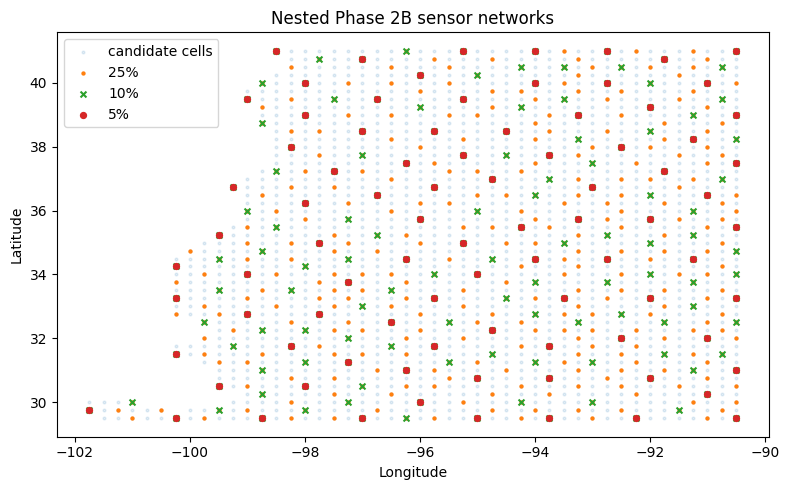

Sparse Phase 2B-1 data preparation is ready.


In [10]:

def time_index_exact(timestamp):
    ts = pd.Timestamp(timestamp)
    hits = np.where(times == ts)[0]
    if len(hits) != 1:
        raise ValueError(f"Forecast origin {ts} is not exactly present.")
    return int(hits[0])


def valid_pressure_mask(time_idx, p_hpa):
    return (SP_PA[time_idx] / 100.0) >= (float(p_hpa) + SURFACE_PRESSURE_MARGIN_HPA)


lon2, lat2 = np.meshgrid(lons, lats)
x2_full, y2_full = np.meshgrid(x_km, y_km)
FULL_XY_POINTS = np.column_stack([x2_full.ravel(), y2_full.ravel()])

INNER_XY = (
    (lat2 >= EVAL_LAT_BOUNDS[0])
    & (lat2 <= EVAL_LAT_BOUNDS[1])
    & (lon2 >= EVAL_LON_BOUNDS[0])
    & (lon2 <= EVAL_LON_BOUNDS[1])
)


def utc_phase_from_abs_hour(abs_hour):
    base_hour = times[0].hour + times[0].minute/60.0 + times[0].second/3600.0
    hour_of_day = np.mod(base_hour + np.asarray(abs_hour), 24.0)
    angle = 2.0 * np.pi * hour_of_day / 24.0
    return np.sin(angle), np.cos(angle)


def farthest_point_sample(candidate_xy, n_select, seed):
    candidate_xy = np.asarray(candidate_xy, dtype=float)
    n = len(candidate_xy)

    if n_select >= n:
        return np.arange(n, dtype=int)
    if n_select < 1:
        raise ValueError("n_select must be >= 1.")

    rng = np.random.default_rng(seed)
    first = int(rng.integers(0, n))

    selected = np.empty(n_select, dtype=int)
    selected[0] = first

    min_d2 = np.sum((candidate_xy - candidate_xy[first])**2, axis=1)
    min_d2[first] = -np.inf

    for k in range(1, n_select):
        idx = int(np.argmax(min_d2))
        selected[k] = idx
        d2 = np.sum((candidate_xy - candidate_xy[idx])**2, axis=1)
        min_d2 = np.minimum(min_d2, d2)
        min_d2[selected[:k+1]] = -np.inf

    return selected


def build_common_candidate_mask():
    relevant_time_indices = set()

    for origin in FORECAST_ORIGINS:
        oi = time_index_exact(origin)
        for it in range(oi - HISTORY_HOURS, oi + 1):
            relevant_time_indices.add(it)

    candidate = np.ones((len(lats), len(lons)), dtype=bool)

    for it in sorted(relevant_time_indices):
        for p in levels:
            candidate &= valid_pressure_mask(it, p)

    if not candidate.any():
        raise RuntimeError("No common physically valid sensor candidates.")

    return candidate


SENSOR_CANDIDATE_MASK = build_common_candidate_mask()
candidate_y, candidate_x = np.where(SENSOR_CANDIDATE_MASK)
candidate_xy = np.column_stack([x_km[candidate_x], y_km[candidate_y]])
n_candidates = len(candidate_xy)

# Build one farthest-point ordering up to 25%; all lower-density networks use prefixes.
max_fraction = max(max(DENSITIES_TO_RUN), 0.10)
n_max = max(
    MIN_SENSOR_COUNT,
    int(np.ceil(max_fraction * n_candidates))
)
n_max = min(n_max, n_candidates)

SENSOR_ORDER_LOCAL = farthest_point_sample(
    candidate_xy,
    n_select=n_max,
    seed=SENSOR_SELECTION_SEED,
)


def sensor_mask_for_fraction(frac):
    n_select = max(
        MIN_SENSOR_COUNT,
        int(np.ceil(float(frac) * n_candidates))
    )
    n_select = min(n_select, n_candidates)

    if n_select > len(SENSOR_ORDER_LOCAL):
        raise RuntimeError("Requested density exceeds precomputed nested sensor ordering.")

    chosen = SENSOR_ORDER_LOCAL[:n_select]
    mask = np.zeros_like(SENSOR_CANDIDATE_MASK, dtype=bool)
    mask[candidate_y[chosen], candidate_x[chosen]] = True
    return mask, n_select


# Consistency with the already-executed 10% notebook.
mask_25, n25 = sensor_mask_for_fraction(0.25)
mask_10, n10 = sensor_mask_for_fraction(0.10)
mask_05, n05 = sensor_mask_for_fraction(0.05)

assert n_candidates == 1723, (
    f"Candidate count changed: expected 1723 from the successful 10% run, got {n_candidates}."
)
assert n10 == 173, (
    f"10% sensor count changed: expected 173 from the successful run, got {n10}."
)
assert np.all(~mask_05 | mask_10)
assert np.all(~mask_10 | mask_25)

print(f"Candidate cells: {n_candidates}")
print(f"25% nested sensors: {n25}")
print(f"10% nested sensors: {n10}  (matches executed Phase 2B-1)")
print(f" 5% nested sensors: {n05}")
print("Nested-network checks PASSED: 5% ⊂ 10% ⊂ 25%")

fig, ax = plt.subplots(figsize=(8, 5))
cy, cx = np.where(SENSOR_CANDIDATE_MASK)
ax.scatter(lons[cx], lats[cy], s=4, alpha=0.12, label="candidate cells")

for frac, mask, marker in [
    (0.25, mask_25, "."),
    (0.10, mask_10, "x"),
    (0.05, mask_05, "o"),
]:
    sy, sx = np.where(mask)
    ax.scatter(lons[sx], lats[sy], s=18, marker=marker, label=f"{int(frac*100)}%")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Nested Phase 2B sensor networks")
ax.legend()
plt.tight_layout()
plt.show()


@dataclass
class OriginBundle:
    origin: pd.Timestamp
    origin_idx: int

    # Sparse labeled training data only.
    train_coords: np.ndarray
    train_theta: np.ndarray
    train_meta: np.ndarray
    train_forcing_extra: np.ndarray

    # Reconstructed sparse initial background on the full model grid.
    ic_xy: np.ndarray
    ic_background_levels: np.ndarray
    ic_valid_levels: np.ndarray

    # Sparse trend-slope background on the full model grid.
    trend_slope_levels: np.ndarray

    data_scale: float
    tendency_scale: float
    forcing_mean: np.ndarray
    forcing_std: np.ndarray

    past_phys: dict
    future_phys: dict
    future_boundary: dict


def build_grid_rows(time_indices, origin_idx, inner_only=False, sensor_only=False):
    coords_list, theta_list, meta_list, extra_list = [], [], [], []
    xy_selector = INNER_XY if inner_only else np.ones((len(lats), len(lons)), dtype=bool)

    if sensor_only:
        xy_selector = xy_selector & SENSOR_MASK

    for it in time_indices:
        tau = float(hours_from_start[it] - hours_from_start[origin_idx])
        s_t, c_t = utc_phase_from_abs_hour(hours_from_start[it])

        for ip, p in enumerate(levels):
            valid = (
                valid_pressure_mask(it, p)
                & valid_pressure_mask(origin_idx, p)
                & xy_selector
            )
            iy, ix = np.where(valid)
            if len(iy) == 0:
                continue

            n = len(iy)
            coords = np.column_stack([
                x_km[ix],
                y_km[iy],
                np.full(n, p),
                np.full(n, tau),
            ])

            theta = THETA_K[it, ip, iy, ix]

            meta = np.column_stack([
                np.full(n, it, dtype=int),
                np.full(n, ip, dtype=int),
                iy.astype(int),
                ix.astype(int),
            ])

            extra = np.column_stack([
                U_KM_H[it, ip, iy, ix],
                V_KM_H[it, ip, iy, ix],
                OMEGA_HPA_H[it, ip, iy, ix],
                Q_SPEC[it, ip, iy, ix],
                LATENT_THETA_K_H[it, ip, iy, ix],
                np.full(n, s_t),
                np.full(n, c_t),
            ])

            coords_list.append(coords)
            theta_list.append(theta)
            meta_list.append(meta)
            extra_list.append(extra)

    if not coords_list:
        raise RuntimeError("No rows were created for the requested grid/time selection.")

    return (
        np.concatenate(coords_list, axis=0),
        np.concatenate(theta_list, axis=0),
        np.concatenate(meta_list, axis=0),
        np.concatenate(extra_list, axis=0),
    )


def interpolate_sparse_to_full_grid(sensor_mask, values_2d, valid_target_mask):
    """
    Reconstruct a full 2D background using only sensor values.

    Linear interpolation is used where supported by the sensor convex hull;
    nearest-neighbor interpolation fills any remaining target cells.
    """
    sy, sx = np.where(sensor_mask)
    if len(sy) < 3:
        raise RuntimeError("Need at least 3 sensor points for 2D interpolation.")

    obs_xy = np.column_stack([x_km[sx], y_km[sy]])
    obs_values = values_2d[sy, sx]

    if not np.isfinite(obs_values).all():
        raise RuntimeError("Non-finite sparse observation encountered.")

    linear = griddata(
        obs_xy,
        obs_values,
        FULL_XY_POINTS,
        method="linear",
    ).reshape(len(lats), len(lons))

    nearest = griddata(
        obs_xy,
        obs_values,
        FULL_XY_POINTS,
        method="nearest",
    ).reshape(len(lats), len(lons))

    background = np.where(np.isfinite(linear), linear, nearest)

    # Values outside the physically valid target domain do not enter data loss
    # or evaluation at that pressure level; keep finite interpolation support
    # for autograd near terrain boundaries.
    if not np.isfinite(background).all():
        raise RuntimeError("Sparse interpolation produced non-finite background values.")

    return background


def build_sparse_initial_and_trend(origin_idx):
    """
    Build t=0 background and 4-hour trend from sparse sensor observations only.
    """
    bg_levels = []
    slope_levels = []
    valid_levels = []

    trend_idx = np.arange(origin_idx - TREND_HOURS + 1, origin_idx + 1)
    trend_tau = hours_from_start[trend_idx] - hours_from_start[origin_idx]
    tc = trend_tau - trend_tau.mean()
    denom = np.sum(tc**2)

    for ip, p in enumerate(levels):
        valid0 = valid_pressure_mask(origin_idx, p)

        # All selected sensors were constructed to be valid throughout the
        # relevant training histories, so these values are legitimate.
        theta0_grid = THETA_K[origin_idx, ip]
        bg = interpolate_sparse_to_full_grid(
            SENSOR_MASK,
            theta0_grid,
            valid0,
        )

        # Sensor-only temporal slope.
        hist = THETA_K[trend_idx, ip]  # [time,y,x]
        hist_mean = np.mean(hist, axis=0)
        slope_full_truth = np.sum(
            tc[:, None, None] * (hist - hist_mean[None, ...]),
            axis=0,
        ) / denom

        slope_bg = interpolate_sparse_to_full_grid(
            SENSOR_MASK,
            slope_full_truth,
            valid0,
        )

        bg_levels.append(bg)
        slope_levels.append(slope_bg)
        valid_levels.append(valid0)

    # [ncell, nlevel] format for compatibility with the existing initial-field code.
    bg_flat = np.column_stack([g.ravel() for g in bg_levels])
    valid_flat = np.column_stack([v.ravel() for v in valid_levels])

    return (
        FULL_XY_POINTS.copy(),
        bg_flat,
        valid_flat,
        np.stack(slope_levels, axis=0),
    )


def sample_collocation_pool(origin_idx, tau_low, tau_high, n_target, boundary=False, seed=0):
    rng = np.random.default_rng(seed)
    chunks = {k: [] for k in ["coords", "u", "v", "w", "latent", "sin", "cos"]}

    def current_n():
        return sum(len(a) for a in chunks["u"])

    attempts = 0
    while current_n() < n_target:
        attempts += 1
        if attempts > 100:
            raise RuntimeError("Unable to generate enough valid collocation points.")

        m = max(4096, n_target // 2)
        tau = rng.uniform(tau_low, tau_high, size=m)

        # Continuous pressure collocation, inherited from successful Phase 2A v3.
        p = rng.uniform(float(levels[0]), float(levels[-1]), size=m)

        if boundary:
            side = rng.integers(0, 4, size=m)
            x = rng.uniform(x_km[0], x_km[-1], size=m)
            y = rng.uniform(y_km[0], y_km[-1], size=m)
            x[side == 0] = x_km[0]
            x[side == 1] = x_km[-1]
            y[side == 2] = y_km[0]
            y[side == 3] = y_km[-1]
        else:
            x = rng.uniform(x_km[0], x_km[-1], size=m)
            y = rng.uniform(y_km[0], y_km[-1], size=m)

        abs_hour = hours_from_start[origin_idx] + tau
        pts4 = np.column_stack([abs_hour, p, y, x])
        pts3 = np.column_stack([abs_hour, y, x])
        pts3_0 = np.column_stack([
            np.full(m, hours_from_start[origin_idx]),
            y,
            x,
        ])

        sp_now = SP_interp(pts3)
        sp_0 = SP_interp(pts3_0)

        valid = (
            np.isfinite(sp_now)
            & np.isfinite(sp_0)
            & (sp_now >= p + SURFACE_PRESSURE_MARGIN_HPA)
            & (sp_0 >= p + SURFACE_PRESSURE_MARGIN_HPA)
        )
        if not valid.any():
            continue

        pts4_v = pts4[valid]
        u = U_interp(pts4_v)
        v = V_interp(pts4_v)
        w = W_interp(pts4_v)
        latent = LAT_interp(pts4_v)

        fv = np.isfinite(u) & np.isfinite(v) & np.isfinite(w) & np.isfinite(latent)
        if not fv.any():
            continue

        idx = np.where(valid)[0][fv]
        coords = np.column_stack([x[idx], y[idx], p[idx], tau[idx]])
        s_t, c_t = utc_phase_from_abs_hour(abs_hour[idx])

        chunks["coords"].append(coords)
        chunks["u"].append(u[fv])
        chunks["v"].append(v[fv])
        chunks["w"].append(w[fv])
        chunks["latent"].append(latent[fv])
        chunks["sin"].append(s_t)
        chunks["cos"].append(c_t)

    result = {k: np.concatenate(v, axis=0)[:n_target] for k, v in chunks.items()}

    forbidden = {"theta", "temperature", "target", "truth", "T"}
    assert forbidden.isdisjoint(result.keys())
    return result


def prepare_origin(origin, pool_seed=12345):
    oi = time_index_exact(origin)

    if oi - HISTORY_HOURS < 0:
        raise ValueError("Insufficient history.")
    if oi + FORECAST_HOURS >= len(times):
        raise ValueError("Insufficient future hours.")

    # Sparse temperature labels only.
    past_indices = list(range(oi - HISTORY_HOURS, oi))
    train_coords, train_theta, train_meta, train_extra = build_grid_rows(
        past_indices,
        oi,
        inner_only=False,
        sensor_only=True,
    )

    assert np.max(train_coords[:, 3]) < 0.0
    assert np.min(train_coords[:, 3]) >= -HISTORY_HOURS

    ic_xy, ic_background, ic_valid, trend_slope_levels = build_sparse_initial_and_trend(oi)

    # Compute scale using sparse training labels and sparse-background t0 values
    # at those same sensor locations.
    ip = train_meta[:, 1].astype(int)
    iy = train_meta[:, 2].astype(int)
    ix = train_meta[:, 3].astype(int)

    ic_bg_grid = np.stack(
        [
            ic_background[:, j].reshape(len(lats), len(lons))
            for j in range(len(levels))
        ],
        axis=0,
    )
    theta0_bg_at_train = ic_bg_grid[ip, iy, ix]
    data_scale = max(float(np.std(train_theta - theta0_bg_at_train)), 0.5)

    # Sparse-only temporal tendency scale.
    sparse_tendency_values = []
    for it in range(oi - HISTORY_HOURS, oi):
        next_it = it + 1
        for ip_, p in enumerate(levels):
            valid = (
                SENSOR_MASK
                & valid_pressure_mask(it, p)
                & valid_pressure_mask(next_it, p)
            )
            if valid.any():
                sparse_tendency_values.append(
                    (THETA_K[next_it, ip_] - THETA_K[it, ip_])[valid]
                )

    sparse_tendency_values = np.concatenate(sparse_tendency_values)
    tendency_scale = max(float(np.std(sparse_tendency_values)), 0.10)

    forcing_mean = np.nanmean(train_extra, axis=0)
    forcing_std = np.nanstd(train_extra, axis=0)
    forcing_std = np.where(forcing_std < 1e-8, 1.0, forcing_std)

    past_phys = sample_collocation_pool(
        oi, -HISTORY_HOURS, 0.0, PAST_PHYS_POOL,
        boundary=False, seed=pool_seed + oi
    )
    future_phys = sample_collocation_pool(
        oi, 0.0, FORECAST_HOURS, FUTURE_PHYS_POOL,
        boundary=False, seed=pool_seed + 1000 + oi
    )
    future_boundary = sample_collocation_pool(
        oi, 0.0, FORECAST_HOURS, BOUNDARY_POOL,
        boundary=True, seed=pool_seed + 2000 + oi
    )

    return OriginBundle(
        origin=pd.Timestamp(origin),
        origin_idx=oi,
        train_coords=train_coords,
        train_theta=train_theta,
        train_meta=train_meta,
        train_forcing_extra=train_extra,
        ic_xy=ic_xy,
        ic_background_levels=ic_background,
        ic_valid_levels=ic_valid,
        trend_slope_levels=trend_slope_levels,
        data_scale=data_scale,
        tendency_scale=tendency_scale,
        forcing_mean=forcing_mean,
        forcing_std=forcing_std,
        past_phys=past_phys,
        future_phys=future_phys,
        future_boundary=future_boundary,
    )


print("Sparse Phase 2B-1 data preparation is ready.")



## Differentiable sparse initial background

Unlike Phase 2A-R, Phase 2B does **not** use the full ERA5 \(t=0\) temperature field.

The initial field supplied to every learned model is the spatial interpolation of the current sparse sensor observations constructed above.

The existing differentiable bilinear initial-field object is retained, but it now interpolates the **sparse reconstructed background**, not full ERA5 truth.

A consistency test checks that the differentiable representation reproduces its own sparse-background grid to floating-point tolerance. This is a code check, not a comparison to hidden full \(t=0\) truth.


In [11]:

class ExactInitialField(nn.Module):
    # Frozen bilinear interpolation of a supplied 3-level background grid.
    def __init__(self, level_grids):
        super().__init__()
        self.register_buffer("x_axis", torch.tensor(x_km, dtype=torch.float32))
        self.register_buffer("y_axis", torch.tensor(y_km, dtype=torch.float32))
        self.register_buffer("grids", torch.tensor(level_grids, dtype=torch.float32))

    def forward(self, xy):
        xq = torch.clamp(xy[:, 0], self.x_axis[0], self.x_axis[-1])
        yq = torch.clamp(xy[:, 1], self.y_axis[0], self.y_axis[-1])

        ix = torch.searchsorted(self.x_axis, xq, right=True) - 1
        iy = torch.searchsorted(self.y_axis, yq, right=True) - 1

        ix = torch.clamp(ix, 0, len(self.x_axis) - 2)
        iy = torch.clamp(iy, 0, len(self.y_axis) - 2)

        x0 = self.x_axis[ix]
        x1 = self.x_axis[ix + 1]
        y0 = self.y_axis[iy]
        y1 = self.y_axis[iy + 1]

        wx = ((xq - x0) / (x1 - x0)).unsqueeze(1)
        wy = ((yq - y0) / (y1 - y0)).unsqueeze(1)

        f00 = self.grids[:, iy,     ix    ].T
        f10 = self.grids[:, iy,     ix + 1].T
        f01 = self.grids[:, iy + 1, ix    ].T
        f11 = self.grids[:, iy + 1, ix + 1].T

        return (
            (1.0 - wx) * (1.0 - wy) * f00
            + wx * (1.0 - wy) * f10
            + (1.0 - wx) * wy * f01
            + wx * wy * f11
        )


def build_sparse_initial_field(bundle):
    level_grids = np.stack(
        [
            bundle.ic_background_levels[:, j].reshape(len(lats), len(lons))
            for j in range(len(levels))
        ],
        axis=0,
    )

    model = ExactInitialField(level_grids).to(device)
    model.eval()

    xy_t = torch.tensor(bundle.ic_xy, dtype=torch.float32, device=device)
    with torch.no_grad():
        pred = model(xy_t).cpu().numpy()

    truth_background = bundle.ic_background_levels
    err = pred - truth_background
    rmse_background = float(np.sqrt(np.mean(err**2)))

    print(f"    Sparse-background representation RMSE={rmse_background:.8f} K")

    if rmse_background > EXACT_IC_GRID_RMSE_TOL_K:
        raise RuntimeError(
            f"Sparse-background differentiable representation failed: "
            f"{rmse_background:.8f} K > {EXACT_IC_GRID_RMSE_TOL_K:.8f} K"
        )

    for par in model.parameters():
        par.requires_grad_(False)

    return model, rmse_background


## Anchored forecast models

In [12]:
def make_mlp(in_dim, out_dim, hidden, layers):
    modules = [nn.Linear(in_dim, hidden), nn.Tanh()]
    for _ in range(layers - 1):
        modules += [nn.Linear(hidden, hidden), nn.Tanh()]
    modules += [nn.Linear(hidden, out_dim)]
    return nn.Sequential(*modules)


def lagrange_weights(p):
    p0, p1, p2 = [float(v) for v in levels]
    L0 = (p-p1)*(p-p2)/((p0-p1)*(p0-p2))
    L1 = (p-p0)*(p-p2)/((p1-p0)*(p1-p2))
    L2 = (p-p0)*(p-p1)/((p2-p0)*(p2-p1))
    return torch.stack([L0,L1,L2], dim=1)

class AnchoredCoordinateModel(nn.Module):
    def __init__(self, ic_model, delta_scale):
        super().__init__()
        self.ic_model = ic_model
        self.delta_scale = float(delta_scale)
        self.xmin, self.xmax = float(x_km[0]), float(x_km[-1])
        self.ymin, self.ymax = float(y_km[0]), float(y_km[-1])
        self.pmin, self.pmax = float(levels[0]), float(levels[-1])
        self.net = make_mlp(4, 1, HIDDEN, LAYERS)

    def initial_theta(self, coords):
        vals = self.ic_model(coords[:,:2])
        return torch.sum(vals * lagrange_weights(coords[:,2]), dim=1)

    def norm_coords(self, coords):
        x = 2.0*(coords[:,0]-self.xmin)/(self.xmax-self.xmin)-1.0
        y = 2.0*(coords[:,1]-self.ymin)/(self.ymax-self.ymin)-1.0
        p = 2.0*(coords[:,2]-self.pmin)/(self.pmax-self.pmin)-1.0
        tau = coords[:,3] / HISTORY_HOURS
        return torch.stack([x,y,p,tau], dim=1)

    def forward(self, coords):
        base = self.initial_theta(coords)
        corr = self.net(self.norm_coords(coords)).squeeze(1)
        return base + (coords[:,3]/HISTORY_HOURS) * self.delta_scale * corr

class AnchoredForcingModel(nn.Module):
    def __init__(self, ic_model, delta_scale, forcing_mean, forcing_std):
        super().__init__()
        self.ic_model = ic_model
        self.delta_scale = float(delta_scale)
        self.xmin, self.xmax = float(x_km[0]), float(x_km[-1])
        self.ymin, self.ymax = float(y_km[0]), float(y_km[-1])
        self.pmin, self.pmax = float(levels[0]), float(levels[-1])
        self.register_buffer("fmean", torch.tensor(forcing_mean, dtype=torch.float32))
        self.register_buffer("fstd", torch.tensor(forcing_std, dtype=torch.float32))
        self.net = make_mlp(4+len(forcing_mean), 1, HIDDEN, LAYERS)

    def initial_theta(self, coords):
        vals = self.ic_model(coords[:,:2])
        return torch.sum(vals * lagrange_weights(coords[:,2]), dim=1)

    def norm_coords(self, coords):
        x = 2.0*(coords[:,0]-self.xmin)/(self.xmax-self.xmin)-1.0
        y = 2.0*(coords[:,1]-self.ymin)/(self.ymax-self.ymin)-1.0
        p = 2.0*(coords[:,2]-self.pmin)/(self.pmax-self.pmin)-1.0
        tau = coords[:,3] / HISTORY_HOURS
        return torch.stack([x,y,p,tau], dim=1)

    def forward(self, coords, extra):
        base = self.initial_theta(coords)
        z = torch.cat(
            [self.norm_coords(coords), (extra-self.fmean)/self.fstd],
            dim=1
        )
        corr = self.net(z).squeeze(1)
        return base + (coords[:,3]/HISTORY_HOURS) * self.delta_scale * corr

print("Anchored models ready.")


Anchored models ready.


## Heating closure and PINN residual

In [13]:

class HeatingClosure(nn.Module):
    def __init__(self):
        super().__init__()
        self.raw_latent = nn.Parameter(torch.tensor(0.0))  # sigmoid -> alpha=1 initially
        self.raw_b0 = nn.Parameter(torch.tensor(0.0))
        self.raw_bp = nn.Parameter(torch.tensor(0.0))
        self.raw_bs = nn.Parameter(torch.tensor(0.0))
        self.raw_bc = nn.Parameter(torch.tensor(0.0))

    def coefficients(self):
        alpha = MAX_LATENT_SCALE * torch.sigmoid(self.raw_latent)
        b0 = MAX_B0_K_PER_H * torch.tanh(self.raw_b0)
        bp = MAX_BP_K_PER_H * torch.tanh(self.raw_bp)
        bs = MAX_DIURNAL_K_PER_H * torch.tanh(self.raw_bs)
        bc = MAX_DIURNAL_K_PER_H * torch.tanh(self.raw_bc)
        return alpha,b0,bp,bs,bc

    def source(self, p, latent, sin_t, cos_t):
        alpha,b0,bp,bs,bc = self.coefficients()
        p_star = (p-850.0)/150.0
        return alpha*latent + b0 + bp*p_star + bs*sin_t + bc*cos_t

    def regularization(self):
        _,b0,bp,bs,bc = self.coefficients()
        return (
            (b0/MAX_B0_K_PER_H)**2
            + (bp/MAX_BP_K_PER_H)**2
            + (bs/MAX_DIURNAL_K_PER_H)**2
            + (bc/MAX_DIURNAL_K_PER_H)**2
        )

def pool_to_tensors(pool):
    return {k: torch.tensor(v, dtype=torch.float32, device=device) for k,v in pool.items()}

def sample_pool_batch(pool_t, batch_size, tau_max=None):
    coords = pool_t["coords"]
    if tau_max is None:
        eligible = torch.arange(len(coords), device=device)
    else:
        eligible = torch.where(coords[:,3] <= float(tau_max)+1e-7)[0]
    if len(eligible) == 0:
        raise RuntimeError("No eligible pool points.")
    chosen = eligible[torch.randint(0, len(eligible), (min(batch_size, len(eligible)),), device=device)]
    return {k: v[chosen] for k,v in pool_t.items()}

def pde_residual(model, closure, batch):
    # coords are physical x[km], y[km], p[hPa], tau[h]
    coords = batch["coords"].clone().detach().requires_grad_(True)
    theta = model(coords)

    grads = torch.autograd.grad(
        theta, coords,
        grad_outputs=torch.ones_like(theta),
        create_graph=True,
    )[0]

    source = closure.source(
        coords[:,2], batch["latent"], batch["sin"], batch["cos"]
    )

    residual = (
        grads[:,3]
        + batch["u"] * grads[:,0]
        + batch["v"] * grads[:,1]
        + batch["w"] * grads[:,2]
        - source
    )
    return residual



## Manufactured-solution test
For \(	heta=a+Ax+By+Cp+Dt\), exact source is \(D+uA+vB+\omega C\). The implemented residual must be zero.


In [14]:

class ManufacturedModel(nn.Module):
    def __init__(self, a,A,B,C,D):
        super().__init__()
        self.a,self.A,self.B,self.C,self.D = map(float,[a,A,B,C,D])
    def forward(self, coords):
        return (
            self.a
            + self.A*coords[:,0]
            + self.B*coords[:,1]
            + self.C*coords[:,2]
            + self.D*coords[:,3]
        )

class ManufacturedClosure(nn.Module):
    def __init__(self, exact_source):
        super().__init__()
        self.exact_source = float(exact_source)
    def source(self, p, latent, sin_t, cos_t):
        return torch.full_like(p, self.exact_source)

a,A,B,Cc,D = 300.0,0.01,-0.02,0.003,0.40
u0,v0,w0 = 25.0,-10.0,4.0
source0 = D + u0*A + v0*B + w0*Cc

coords_test = torch.tensor(
    [[0.0,0.0,850.0,1.0],
     [100.0,50.0,925.0,2.5],
     [-80.0,-40.0,700.0,-3.0]],
    dtype=torch.float32, device=device
)
batch_test = {
    "coords": coords_test,
    "u": torch.full((3,), u0, device=device),
    "v": torch.full((3,), v0, device=device),
    "w": torch.full((3,), w0, device=device),
    "latent": torch.zeros(3, device=device),
    "sin": torch.zeros(3, device=device),
    "cos": torch.zeros(3, device=device),
}

r = pde_residual(
    ManufacturedModel(a,A,B,Cc,D).to(device),
    ManufacturedClosure(source0).to(device),
    batch_test
).detach().cpu().numpy()

print("Manufactured residual:", r)
assert np.max(np.abs(r)) < 1e-5
print("MANUFACTURED PDE TEST PASSED.")


Manufactured residual: [0. 0. 0.]
MANUFACTURED PDE TEST PASSED.



## Buffer diagnostic
No future temperature boundary values are supplied. The outer boundary receives only a weak persistence penalty, while scoring is performed 4° inside. The notebook stops if the 99th-percentile 3-h wind displacement reaches the available horizontal buffer.


In [15]:

buffer_y_km = BUFFER_DEG * KM_PER_DEG_LAT
buffer_x_km = BUFFER_DEG * KM_PER_DEG_LON
min_buffer_km = min(buffer_x_km, buffer_y_km)

origin_indices = [time_index_exact(o) for o in FORECAST_ORIGINS]
future_idx = sorted(set(
    j for oi in origin_indices
    for j in range(oi+1, oi+FORECAST_HOURS+1)
))

wind = np.sqrt(U_KM_H[future_idx]**2 + V_KM_H[future_idx]**2)
wind_q99 = float(np.nanpercentile(wind, 99))
disp_q99 = wind_q99 * FORECAST_HOURS

print(f"Minimum buffer: {min_buffer_km:.1f} km")
print(f"99th-percentile wind: {wind_q99:.1f} km/h")
print(f"3-h displacement: {disp_q99:.1f} km")

if disp_q99 >= min_buffer_km:
    raise RuntimeError(
        "3-h 99th-percentile advective displacement reaches/exceeds the buffer. "
        "Increase BUFFER_DEG before interpreting Phase 2A."
    )

print("BUFFER DIAGNOSTIC PASSED.")


Minimum buffer: 362.6 km
99th-percentile wind: 63.6 km/h
3-h displacement: 190.8 km
BUFFER DIAGNOSTIC PASSED.


## Baseline training

In [16]:

def random_idx(n, batch_size):
    return torch.randint(0, n, (min(batch_size,n),), device=device)

def train_coordinate_baseline(bundle, ic_model, seed):
    set_seed(seed)
    model = AnchoredCoordinateModel(ic_model, bundle.data_scale).to(device)
    coords = torch.tensor(bundle.train_coords, dtype=torch.float32, device=device)
    target = torch.tensor(bundle.train_theta, dtype=torch.float32, device=device)

    opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=TOTAL_MAIN_STEPS, eta_min=1e-5
    )

    for _ in range(TOTAL_MAIN_STEPS):
        idx = random_idx(len(coords), DATA_BATCH)
        pred = model(coords[idx])
        loss = torch.mean(((pred-target[idx])/bundle.data_scale)**2)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step()
        sch.step()

    return model

def train_forcing_baseline(bundle, ic_model, seed):
    set_seed(seed + 10000)
    model = AnchoredForcingModel(
        ic_model, bundle.data_scale, bundle.forcing_mean, bundle.forcing_std
    ).to(device)

    coords = torch.tensor(bundle.train_coords, dtype=torch.float32, device=device)
    target = torch.tensor(bundle.train_theta, dtype=torch.float32, device=device)
    extra = torch.tensor(bundle.train_forcing_extra, dtype=torch.float32, device=device)

    opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=TOTAL_MAIN_STEPS, eta_min=1e-5
    )

    for _ in range(TOTAL_MAIN_STEPS):
        idx = random_idx(len(coords), DATA_BATCH)
        pred = model(coords[idx], extra[idx])
        loss = torch.mean(((pred-target[idx])/bundle.data_scale)**2)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step()
        sch.step()

    return model



## Causal PINN training
Stage A learns the network and low-dimensional closure using past labels and past physics. Then closure coefficients are frozen, and future unlabeled physics is expanded causally to +1 h, +2 h, and +3 h.


In [17]:

def closure_values(closure):
    with torch.no_grad():
        return [float(v.detach().cpu()) for v in closure.coefficients()]

def train_pinn(bundle, ic_model, seed):
    set_seed(seed)

    model = AnchoredCoordinateModel(ic_model, bundle.data_scale).to(device)
    closure = HeatingClosure().to(device)

    coords = torch.tensor(bundle.train_coords, dtype=torch.float32, device=device)
    target = torch.tensor(bundle.train_theta, dtype=torch.float32, device=device)

    past_pool = pool_to_tensors(bundle.past_phys)
    future_pool = pool_to_tensors(bundle.future_phys)
    boundary_pool = pool_to_tensors(bundle.future_boundary)

    # Stage A: learn closure from past only.
    params = list(model.parameters()) + list(closure.parameters())
    opt = torch.optim.Adam(params, lr=LEARNING_RATE)

    for step in range(STAGE_A_STEPS):
        idx = random_idx(len(coords), DATA_BATCH)

        pred = model(coords[idx])
        data_loss = torch.mean(((pred-target[idx])/bundle.data_scale)**2)

        pb = sample_pool_batch(past_pool, PHYS_BATCH)
        res = pde_residual(model, closure, pb)
        phys_loss = torch.mean((res/bundle.tendency_scale)**2)

        loss = (
            data_loss
            + LAMBDA_PHYSICS*phys_loss
            + LAMBDA_SOURCE_REG*closure.regularization()
        )

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
        opt.step()

        if step % 500 == 0:
            print(
                f"      Stage A {step:4d}/{STAGE_A_STEPS} "
                f"data={data_loss.item():.4f} physics={phys_loss.item():.4f}"
            )

    frozen_closure = closure_values(closure)
    for par in closure.parameters():
        par.requires_grad_(False)

    # Future causal stages.
    for horizon in range(1, FORECAST_HOURS+1):
        opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE*0.5)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=FUTURE_STAGE_STEPS, eta_min=1e-5
        )

        for _ in range(FUTURE_STAGE_STEPS):
            idx = random_idx(len(coords), DATA_BATCH)
            pred = model(coords[idx])
            data_loss = torch.mean(((pred-target[idx])/bundle.data_scale)**2)

            pb0 = sample_pool_batch(past_pool, PHYS_BATCH//2)
            pbf = sample_pool_batch(future_pool, PHYS_BATCH//2, tau_max=horizon)

            r0 = pde_residual(model, closure, pb0)
            rf = pde_residual(model, closure, pbf)
            phys_loss = 0.5*(
                torch.mean((r0/bundle.tendency_scale)**2)
                + torch.mean((rf/bundle.tendency_scale)**2)
            )

            bb = sample_pool_batch(boundary_pool, BOUNDARY_BATCH, tau_max=horizon)
            theta_b = model(bb["coords"])
            theta_0 = model.initial_theta(bb["coords"])
            boundary_loss = torch.mean(((theta_b-theta_0)/bundle.data_scale)**2)

            loss = (
                data_loss
                + LAMBDA_PHYSICS*phys_loss
                + LAMBDA_BOUNDARY*boundary_loss
            )

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            sch.step()

        print(
            f"      Causal +{horizon}h complete | "
            f"data={data_loss.item():.4f}, physics={phys_loss.item():.4f}, "
            f"boundary={boundary_loss.item():.4f}"
        )

    # Closure must be bitwise unchanged after future stages.
    assert np.allclose(frozen_closure, closure_values(closure), atol=0, rtol=0)

    return model, closure



## Future evaluation helpers
**Future temperature truth is constructed only here, after model training for an origin.**


In [18]:

def build_eval_bundle(bundle):
    oi = bundle.origin_idx
    future_indices = list(range(oi + 1, oi + FORECAST_HOURS + 1))

    # Full future ERA5 truth is used only here, for scoring.
    coords, theta_truth, meta, extra = build_grid_rows(
        future_indices,
        oi,
        inner_only=True,
        sensor_only=False,
    )

    ip = meta[:, 1].astype(int)
    iy = meta[:, 2].astype(int)
    ix = meta[:, 3].astype(int)
    tau = coords[:, 3]

    unique_tau = np.unique(tau)
    expected = np.arange(1, FORECAST_HOURS + 1, dtype=float)
    if not np.array_equal(unique_tau, expected):
        raise ValueError(f"Unexpected future lead times: {unique_tau}")

    # Sparse reconstructed t=0 background.
    bg_grid = np.stack(
        [
            bundle.ic_background_levels[:, j].reshape(len(lats), len(lons))
            for j in range(len(levels))
        ],
        axis=0,
    )
    persistence_theta = bg_grid[ip, iy, ix]

    # Sparse sensor-only trend field.
    trend_theta = (
        persistence_theta
        + bundle.trend_slope_levels[ip, iy, ix] * tau
    )

    return {
        "coords": coords,
        "theta_truth": theta_truth,
        "meta": meta,
        "extra": extra,
        "persistence_theta": persistence_theta,
        "trend_theta": trend_theta,
    }


def theta_to_T(theta, p_hpa):
    return theta / ((P0_HPA/p_hpa)**KAPPA)

def rmse(a,b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    return float(np.sqrt(np.mean((a-b)**2)))

def mae(a,b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    return float(np.mean(np.abs(a-b)))

def corr(a,b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return float(np.corrcoef(a,b)[0,1])

def predict_coord(model, coords):
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0,len(coords),8192):
            c = torch.tensor(coords[s:s+8192], dtype=torch.float32, device=device)
            out.append(model(c).cpu().numpy())
    return np.concatenate(out)

def predict_forcing(model, coords, extra):
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0,len(coords),8192):
            c = torch.tensor(coords[s:s+8192], dtype=torch.float32, device=device)
            e = torch.tensor(extra[s:s+8192], dtype=torch.float32, device=device)
            out.append(model(c,e).cpu().numpy())
    return np.concatenate(out)

def future_physics_rms(model, closure, bundle, seed=999):
    pool_t = pool_to_tensors(bundle.future_phys)
    rng = np.random.default_rng(seed)
    n = min(12000, len(bundle.future_phys["coords"]))
    idx_np = rng.choice(len(bundle.future_phys["coords"]), size=n, replace=False)
    idx = torch.tensor(idx_np, dtype=torch.long, device=device)
    sub = {k:v[idx] for k,v in pool_t.items()}
    res = pde_residual(model, closure, sub)
    return float(torch.sqrt(torch.mean(res**2)).detach().cpu())

print("Evaluation helpers ready.")


Evaluation helpers ready.



## Run Phase 2A
For each origin, all trainable models are finished **before** future temperature truth is assembled.


In [19]:

rows = []
closure_rows = []
ic_rows = []

for density in DENSITIES_TO_RUN:
    SENSOR_FRACTION = float(density)
    SENSOR_MASK, n_sensors = sensor_mask_for_fraction(SENSOR_FRACTION)

    print("\n" + "#"*94)
    print(
        f"NEW DENSITY: {100*SENSOR_FRACTION:.0f}% "
        f"({n_sensors}/{n_candidates} sensor locations)"
    )
    print("#"*94)

    for no, origin in enumerate(FORECAST_ORIGINS, start=1):
        print("\n" + "="*90)
        print(
            f"DENSITY {100*SENSOR_FRACTION:.0f}% | "
            f"ORIGIN {no}/{len(FORECAST_ORIGINS)}: {origin} UTC"
        )
        print("="*90)

        bundle = prepare_origin(origin)

        print(
            f"  Sparse past labels: {len(bundle.train_theta):,}; "
            f"tau={bundle.train_coords[:,3].min():.1f} to "
            f"{bundle.train_coords[:,3].max():.1f} h"
        )

        assert bundle.train_coords[:,3].max() < 0.0
        assert "theta" not in bundle.future_phys
        assert "temperature" not in bundle.future_phys

        print("  Building differentiable sparse initial background...")
        ic_model, ic_rep_rmse = build_sparse_initial_field(bundle)

        ic_rows.append({
            "Origin": str(bundle.origin),
            "Sensor_Fraction": SENSOR_FRACTION,
            "N_Sensors": n_sensors,
            "Sparse_Background_Representation_RMSE_K": ic_rep_rmse,
            "N_Past_Temperature_Labels": len(bundle.train_theta),
        })

        trained = []

        for seed in SEEDS:
            print(f"\n  Seed {seed}")

            print("    matched coordinate-only NN")
            data_model = train_coordinate_baseline(bundle, ic_model, seed)

            print("    forcing-aware NN")
            forcing_model = train_forcing_baseline(bundle, ic_model, seed)

            print("    causal PINN")
            pinn_model, closure = train_pinn(bundle, ic_model, seed)

            alpha,b0,bp,bs,bc = closure_values(closure)
            phys_rms = future_physics_rms(pinn_model, closure, bundle)

            closure_rows.append({
                "Origin": str(bundle.origin),
                "Sensor_Fraction": SENSOR_FRACTION,
                "N_Sensors": n_sensors,
                "Seed": seed,
                "latent_scale": alpha,
                "b0_K_per_h": b0,
                "bp_K_per_h": bp,
                "bs_K_per_h": bs,
                "bc_K_per_h": bc,
                "Future_Physics_RMS_K_per_h": phys_rms,
            })

            trained.append(
                (seed, data_model, forcing_model, pinn_model, closure, phys_rms)
            )

        # Future full temperature truth is first used after all models are trained.
        ev = build_eval_bundle(bundle)

        coords_f = ev["coords"]
        p_f = coords_f[:,2]
        tau_f = coords_f[:,3]

        T_truth = theta_to_T(ev["theta_truth"], p_f)
        T_persist = theta_to_T(ev["persistence_theta"], p_f)
        T_trend = theta_to_T(ev["trend_theta"], p_f)

        for seed,data_model,forcing_model,pinn_model,closure,phys_rms in trained:
            T_data = theta_to_T(predict_coord(data_model, coords_f), p_f)
            T_force = theta_to_T(
                predict_forcing(forcing_model, coords_f, ev["extra"]),
                p_f,
            )
            T_pinn = theta_to_T(predict_coord(pinn_model, coords_f), p_f)

            for lead in range(1, FORECAST_HOURS+1):
                m = np.isclose(tau_f, lead)

                r_persist = rmse(T_truth[m], T_persist[m])
                r_trend = rmse(T_truth[m], T_trend[m])
                r_data = rmse(T_truth[m], T_data[m])
                r_force = rmse(T_truth[m], T_force[m])
                r_pinn = rmse(T_truth[m], T_pinn[m])

                baseline = {
                    "Persistence": r_persist,
                    "Trend": r_trend,
                    "MatchedDataNN": r_data,
                    "ForcingAwareNN": r_force,
                }
                best_name = min(baseline, key=baseline.get)
                best_rmse = baseline[best_name]
                improvement = 100.0*(best_rmse-r_pinn)/best_rmse

                rows.append({
                    "Origin": str(bundle.origin),
                    "Sensor_Fraction": SENSOR_FRACTION,
                    "N_Sensors": n_sensors,
                    "Seed": seed,
                    "Lead_h": lead,
                    "N_eval": int(m.sum()),
                    "Persistence_RMSE_K": r_persist,
                    "Trend_RMSE_K": r_trend,
                    "MatchedDataNN_RMSE_K": r_data,
                    "ForcingAwareNN_RMSE_K": r_force,
                    "PINN_RMSE_K": r_pinn,
                    "Best_Baseline": best_name,
                    "Best_Baseline_RMSE_K": best_rmse,
                    "PINN_Improvement_vs_Best_pct": improvement,
                    "PINN_MAE_K": mae(T_truth[m], T_pinn[m]),
                    "PINN_Correlation": corr(T_truth[m], T_pinn[m]),
                    "Future_Physics_RMS_K_per_h": phys_rms,
                })

        del trained
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

new_results = pd.DataFrame(rows)
closures = pd.DataFrame(closure_rows)
ic_results = pd.DataFrame(ic_rows)

print("\nNew 25% and 5% density runs completed.")



##############################################################################################
NEW DENSITY: 25% (431/1723 sensor locations)
##############################################################################################

DENSITY 25% | ORIGIN 1/4: 2026-08-19 12:00:00 UTC
  Sparse past labels: 15,516; tau=-12.0 to -1.0 h
  Building differentiable sparse initial background...
    Sparse-background representation RMSE=0.00000881 K

  Seed 101
    matched coordinate-only NN
    forcing-aware NN
    causal PINN
      Stage A    0/1500 data=1.4403 physics=5.1864
      Stage A  500/1500 data=0.3491 physics=3.2890
      Stage A 1000/1500 data=0.2207 physics=2.0425
      Causal +1h complete | data=0.1720, physics=1.8307, boundary=0.0066
      Causal +2h complete | data=0.1652, physics=1.4531, boundary=0.0515
      Causal +3h complete | data=0.1578, physics=1.4591, boundary=0.0944

  Seed 202
    matched coordinate-only NN
    forcing-aware NN
    causal PINN
      Stage A    0/15


## Executed reference results: 100% dense and 10% sparse

To avoid wasting time rerunning experiments that already completed successfully, this notebook embeds the row-level results from:

- the user's **frozen dense replication notebook**;
- the user's **10% sparse-observation notebook**.

These are data constants, not model outputs generated by this notebook.

Only **25%** and **5%** are newly trained.


In [20]:
DENSE_REFERENCE_CSV = r'''
Origin,Sensor_Fraction,N_Sensors,Seed,Lead_h,N_eval,Persistence_RMSE_K,Trend_RMSE_K,MatchedDataNN_RMSE_K,ForcingAwareNN_RMSE_K,PINN_RMSE_K,Best_Baseline,Best_Baseline_RMSE_K,PINN_Improvement_vs_Best_pct,PINN_MAE_K,PINN_Correlation,Future_Physics_RMS_K_per_h
2026-08-19 12:00:00,1,,101,1,1010,0.640368,0.551407,0.453509,0.489958,0.411168,MatchedDataNN,0.453509,9.336454,0.289508,0.998562,0.490958
2026-08-19 12:00:00,1,,101,2,1010,1.094418,1.026352,0.820127,1.014321,0.666668,MatchedDataNN,0.820127,18.7116,0.511597,0.996519,0.490958
2026-08-19 12:00:00,1,,101,3,1010,1.336449,1.449069,1.242035,1.703521,0.863707,MatchedDataNN,1.242035,30.460325,0.712744,0.995178,0.490958
2026-08-19 12:00:00,1,,202,1,1010,0.640368,0.551407,0.449541,0.489217,0.41167,MatchedDataNN,0.449541,8.424253,0.290871,0.998484,0.49956
2026-08-19 12:00:00,1,,202,2,1010,1.094418,1.026352,0.775537,0.888054,0.657585,MatchedDataNN,0.775537,15.209024,0.500833,0.996351,0.49956
2026-08-19 12:00:00,1,,202,3,1010,1.336449,1.449069,1.111319,1.294742,0.836927,MatchedDataNN,1.111319,24.690659,0.669836,0.995048,0.49956
2026-08-19 18:00:00,1,,101,1,1013,0.743763,0.545389,0.594223,0.482823,0.394278,ForcingAwareNN,0.482823,18.339132,0.312363,0.998901,0.470757
2026-08-19 18:00:00,1,,101,2,1012,1.309834,1.053742,1.215639,0.996549,0.674217,ForcingAwareNN,0.996549,32.344797,0.572198,0.996979,0.470757
2026-08-19 18:00:00,1,,101,3,1011,1.736684,1.55545,1.945105,1.558421,0.977522,Trend,1.55545,37.155013,0.819824,0.994005,0.470757
2026-08-19 18:00:00,1,,202,1,1013,0.743763,0.545389,0.531802,0.476796,0.371644,ForcingAwareNN,0.476796,22.053864,0.285398,0.998996,0.461855
2026-08-19 18:00:00,1,,202,2,1012,1.309834,1.053742,1.122988,0.920202,0.651458,ForcingAwareNN,0.920202,29.204899,0.544777,0.997157,0.461855
2026-08-19 18:00:00,1,,202,3,1011,1.736684,1.55545,1.968365,1.370523,1.007967,ForcingAwareNN,1.370523,26.453859,0.851791,0.993608,0.461855
2026-08-20 12:00:00,1,,101,1,1012,0.354348,0.44281,0.391411,0.297014,0.344152,ForcingAwareNN,0.297014,-15.87061,0.257041,0.998917,0.364101
2026-08-20 12:00:00,1,,101,2,1012,0.595127,0.842507,0.690287,0.583012,0.592133,ForcingAwareNN,0.583012,-1.564404,0.445341,0.996698,0.364101
2026-08-20 12:00:00,1,,101,3,1012,0.703362,1.193843,0.912799,0.859521,0.72683,Persistence,0.703362,-3.336629,0.544983,0.994805,0.364101
2026-08-20 12:00:00,1,,202,1,1012,0.354348,0.44281,0.373755,0.310579,0.347479,ForcingAwareNN,0.310579,-11.881052,0.257513,0.998878,0.361359
2026-08-20 12:00:00,1,,202,2,1012,0.595127,0.842507,0.661337,0.692628,0.597949,Persistence,0.595127,-0.474191,0.454007,0.996558,0.361359
2026-08-20 12:00:00,1,,202,3,1012,0.703362,1.193843,0.878144,1.234376,0.749517,Persistence,0.703362,-6.56203,0.569045,0.99441,0.361359
2026-08-20 18:00:00,1,,101,1,1015,0.746135,0.503141,0.468619,0.386307,0.382943,ForcingAwareNN,0.386307,0.870904,0.254007,0.999067,0.482879
2026-08-20 18:00:00,1,,101,2,1013,1.263263,0.827007,1.025982,0.745926,0.72351,ForcingAwareNN,0.745926,3.005138,0.503076,0.997142,0.482879
2026-08-20 18:00:00,1,,101,3,1012,1.675517,1.227046,1.740086,1.273772,0.846619,Trend,1.227046,31.003442,0.648561,0.995765,0.482879
2026-08-20 18:00:00,1,,202,1,1015,0.746135,0.503141,0.492911,0.564331,0.416418,MatchedDataNN,0.492911,15.518658,0.295883,0.998939,0.482029
2026-08-20 18:00:00,1,,202,2,1013,1.263263,0.827007,1.029008,1.197172,0.778232,Trend,0.827007,5.897783,0.584134,0.996693,0.482029
2026-08-20 18:00:00,1,,202,3,1012,1.675517,1.227046,1.645138,2.025299,0.953348,Trend,1.227046,22.305394,0.754742,0.994732,0.482029
'''

SPARSE10_REFERENCE_CSV = r'''
Origin,Sensor_Fraction,N_Sensors,Seed,Lead_h,N_eval,Persistence_RMSE_K,Trend_RMSE_K,MatchedDataNN_RMSE_K,ForcingAwareNN_RMSE_K,PINN_RMSE_K,Best_Baseline,Best_Baseline_RMSE_K,PINN_Improvement_vs_Best_pct,PINN_MAE_K,PINN_Correlation,Future_Physics_RMS_K_per_h
2026-08-19 12:00:00,0.1,173,101,1,1012,0.630494,0.665404,0.636825,0.712396,0.647504,Persistence,0.630494,-2.697886,0.401966,0.996432,0.704029
2026-08-19 12:00:00,0.1,173,101,2,1012,0.902574,0.950262,0.875186,1.00396,0.762109,MatchedDataNN,0.875186,12.920402,0.581861,0.995769,0.704029
2026-08-19 12:00:00,0.1,173,101,3,1012,1.111662,1.383494,1.398169,1.501355,0.957529,Persistence,1.111662,13.86509,0.762481,0.994194,0.704029
2026-08-19 12:00:00,0.1,173,202,1,1012,0.630494,0.665404,0.633285,0.654546,0.637012,Persistence,0.630494,-1.033734,0.399273,0.996553,0.709839
2026-08-19 12:00:00,0.1,173,202,2,1012,0.902574,0.950262,0.869037,0.838564,0.767034,ForcingAwareNN,0.838564,8.530146,0.589109,0.99559,0.709839
2026-08-19 12:00:00,0.1,173,202,3,1012,1.111662,1.383494,1.317995,1.296301,0.970886,Persistence,1.111662,12.663598,0.773286,0.993487,0.709839
2026-08-19 18:00:00,0.1,173,101,1,1013,0.78859,0.578256,0.558171,0.595879,0.462637,MatchedDataNN,0.558171,17.115579,0.333939,0.998539,0.508836
2026-08-19 18:00:00,0.1,173,101,2,1012,1.315708,0.987899,0.925835,0.941704,0.687935,MatchedDataNN,0.925835,25.695736,0.553769,0.99718,0.508836
2026-08-19 18:00:00,0.1,173,101,3,1011,1.725782,1.428511,1.364134,1.306511,0.964919,ForcingAwareNN,1.306511,26.145342,0.789075,0.994752,0.508836
2026-08-19 18:00:00,0.1,173,202,1,1013,0.78859,0.578256,0.604365,0.586212,0.476876,Trend,0.578256,17.532045,0.353291,0.998444,0.486905
2026-08-19 18:00:00,0.1,173,202,2,1012,1.315708,0.987899,1.055999,1.025588,0.73619,Trend,0.987899,25.479243,0.604164,0.996762,0.486905
2026-08-19 18:00:00,0.1,173,202,3,1011,1.725782,1.428511,1.688745,1.701316,1.064215,Trend,1.428511,25.501777,0.885721,0.993512,0.486905
2026-08-20 12:00:00,0.1,173,101,1,1013,0.47692,0.533329,0.520579,0.545069,0.480366,Persistence,0.47692,-0.722504,0.317371,0.997879,0.419261
2026-08-20 12:00:00,0.1,173,101,2,1013,0.629542,0.817246,0.748691,0.941029,0.63178,Persistence,0.629542,-0.355344,0.458961,0.996347,0.419261
2026-08-20 12:00:00,0.1,173,101,3,1013,0.708805,1.108617,0.963734,1.416808,0.734726,Persistence,0.708805,-3.656997,0.547643,0.995189,0.419261
2026-08-20 12:00:00,0.1,173,202,1,1013,0.47692,0.533329,0.513148,0.646107,0.476831,Persistence,0.47692,0.018726,0.320345,0.997928,0.419884
2026-08-20 12:00:00,0.1,173,202,2,1013,0.629542,0.817246,0.751822,1.281359,0.612391,Persistence,0.629542,2.724459,0.461302,0.996577,0.419884
2026-08-20 12:00:00,0.1,173,202,3,1013,0.708805,1.108617,0.980469,2.109519,0.693471,Persistence,0.708805,2.163361,0.527967,0.995693,0.419884
2026-08-20 18:00:00,0.1,173,101,1,1015,0.774392,0.517225,0.543672,0.481731,0.542043,ForcingAwareNN,0.481731,-12.519796,0.378139,0.998518,0.522942
2026-08-20 18:00:00,0.1,173,101,2,1013,1.292509,0.81894,1.053148,0.803014,0.946039,ForcingAwareNN,0.803014,-17.811129,0.680317,0.996432,0.522942
2026-08-20 18:00:00,0.1,173,101,3,1012,1.709512,1.211925,1.731481,1.195641,1.015913,ForcingAwareNN,1.195641,15.031964,0.722658,0.995227,0.522942
2026-08-20 18:00:00,0.1,173,202,1,1015,0.774392,0.517225,0.569663,0.576874,0.550539,Trend,0.517225,-6.441052,0.380754,0.998434,0.514333
2026-08-20 18:00:00,0.1,173,202,2,1013,1.292509,0.81894,1.090746,1.092188,0.95277,Trend,0.81894,-16.34192,0.685072,0.996144,0.514333
2026-08-20 18:00:00,0.1,173,202,3,1012,1.709512,1.211925,1.714241,1.977007,1.05317,Trend,1.211925,13.099459,0.789539,0.994791,0.514333
'''

dense_reference = pd.read_csv(io.StringIO(DENSE_REFERENCE_CSV))
sparse10_reference = pd.read_csv(io.StringIO(SPARSE10_REFERENCE_CSV))

assert len(dense_reference) == 24
assert len(sparse10_reference) == 24
assert np.isclose(sparse10_reference['Sensor_Fraction'].iloc[0], 0.10)
assert int(sparse10_reference['N_Sensors'].iloc[0]) == 173

print('Embedded executed references loaded:')
print('  dense rows:', len(dense_reference))
print('  10% rows:', len(sparse10_reference))


Embedded executed references loaded:
  dense rows: 24
  10% rows: 24


## Final results and predeclared gate

In [21]:

# Combine new densities with executed references.
density_results = pd.concat(
    [
        dense_reference,
        new_results,
        sparse10_reference,
    ],
    ignore_index=True,
    sort=False,
)

density_results["Sensor_Fraction"] = density_results["Sensor_Fraction"].astype(float)
density_results["Lead_h"] = density_results["Lead_h"].astype(int)

# Stable display order: 100%, 25%, 10%, 5%.
density_order = [1.00, 0.25, 0.10, 0.05]

summary_rows = []
for frac in density_order:
    d = density_results[np.isclose(density_results["Sensor_Fraction"], frac)].copy()
    if len(d) == 0:
        continue

    mean_pinn = float(d["PINN_RMSE_K"].mean())
    mean_best = float(d["Best_Baseline_RMSE_K"].mean())
    improvement = 100.0 * (mean_best - mean_pinn) / mean_best
    win_rate = float(
        (d["PINN_RMSE_K"] < d["Best_Baseline_RMSE_K"]).mean()
    )
    lead3 = d[d["Lead_h"] == FORECAST_HOURS]
    lead3_win = float(
        (lead3["PINN_RMSE_K"] < lead3["Best_Baseline_RMSE_K"]).mean()
    )

    summary_rows.append({
        "Sensor_Fraction": frac,
        "Observed_pct": 100*frac,
        "Mean_PINN_RMSE_K": mean_pinn,
        "Mean_BestBaseline_RMSE_K": mean_best,
        "Mean_PINN_Improvement_pct": improvement,
        "Overall_Win_Rate_pct": 100*win_rate,
        "Lead3_Win_Rate_pct": 100*lead3_win,
    })

density_summary = pd.DataFrame(summary_rows)

lead_rows = []
for frac in density_order:
    d0 = density_results[np.isclose(density_results["Sensor_Fraction"], frac)]
    if len(d0) == 0:
        continue

    for lead in range(1, FORECAST_HOURS+1):
        d = d0[d0["Lead_h"] == lead]
        mean_pinn = float(d["PINN_RMSE_K"].mean())
        mean_best = float(d["Best_Baseline_RMSE_K"].mean())
        improvement = 100.0 * (mean_best - mean_pinn) / mean_best
        win_rate = float(
            (d["PINN_RMSE_K"] < d["Best_Baseline_RMSE_K"]).mean()
        )

        lead_rows.append({
            "Sensor_Fraction": frac,
            "Observed_pct": 100*frac,
            "Lead_h": lead,
            "PINN_RMSE_K": mean_pinn,
            "BestBaseline_RMSE_K": mean_best,
            "PINN_Improvement_pct": improvement,
            "Win_Rate_pct": 100*win_rate,
        })

density_lead_summary = pd.DataFrame(lead_rows)

print("\n" + "="*92)
print("PHASE 2B-2 OBSERVATION-DENSITY × FORECAST-HORIZON SUMMARY")
print("="*92)

print("\nOverall by observation density:")
display(density_summary)

print("\nBy density and forecast lead:")
display(density_lead_summary)

# Secondary practical-gate status at each density; no tuning depends on it.
density_summary["Practical_Gate"] = (
    (density_summary["Mean_PINN_Improvement_pct"] >= MIN_MEAN_IMPROVEMENT_PCT)
    & (density_summary["Overall_Win_Rate_pct"] >= 100*MIN_WIN_RATE)
    & (density_summary["Lead3_Win_Rate_pct"] >= 100*MIN_LEAD3_WIN_RATE)
)

print("\nSame practical gate applied descriptively at every density:")
display(
    density_summary[
        [
            "Observed_pct",
            "Mean_PINN_Improvement_pct",
            "Overall_Win_Rate_pct",
            "Lead3_Win_Rate_pct",
            "Practical_Gate",
        ]
    ]
)

# Save everything needed for paper analysis.
density_results.to_csv(
    "phase2B2_oklahoma_density_curve_all_rows.csv",
    index=False,
)
density_summary.to_csv(
    "phase2B2_oklahoma_density_curve_summary.csv",
    index=False,
)
density_lead_summary.to_csv(
    "phase2B2_oklahoma_density_by_lead_summary.csv",
    index=False,
)
closures.to_csv(
    "phase2B2_oklahoma_newdensity_closure_coefficients.csv",
    index=False,
)
ic_results.to_csv(
    "phase2B2_oklahoma_newdensity_background_diagnostics.csv",
    index=False,
)

print("\nSaved Phase 2B-2 CSV outputs.")



PHASE 2B-2 OBSERVATION-DENSITY × FORECAST-HORIZON SUMMARY

Overall by observation density:


,Sensor_Fraction,Observed_pct,Mean_PINN_RMSE_K,Mean_BestBaseline_RMSE_K,Mean_PINN_Improvement_pct,Overall_Win_Rate_pct,Lead3_Win_Rate_pct
0,1.00,100.0,0.640998,0.781380,17.965921,75.000000,75.0
1,0.25,25.0,0.732886,0.815114,10.087908,75.000000,87.5
2,0.10,10.0,0.742704,0.818427,9.252349,62.500000,87.5
3,0.05,5.0,0.735054,0.814868,9.794729,70.833333,87.5



By density and forecast lead:


,Sensor_Fraction,Observed_pct,Lead_h,PINN_RMSE_K,BestBaseline_RMSE_K,PINN_Improvement_pct,Win_Rate_pct
0,1.00,100.0,1,0.384969,0.418685,8.052832,75.0
1,1.00,100.0,2,0.667719,0.782936,14.716004,75.0
2,1.00,100.0,3,0.870305,1.142518,23.825732,75.0
3,0.25,25.0,1,0.515261,0.529095,2.614772,62.5
4,0.25,25.0,2,0.755082,0.798725,5.464090,75.0
5,0.25,25.0,3,0.928316,1.117522,16.930866,87.5
6,0.10,10.0,1,0.534226,0.543776,1.756306,37.5
7,0.10,10.0,2,0.762031,0.813565,6.334372,62.5
8,0.10,10.0,3,0.931854,1.097940,15.127110,87.5
9,0.05,5.0,1,0.546620,0.554545,1.429172,50.0



Same practical gate applied descriptively at every density:


,Observed_pct,Mean_PINN_Improvement_pct,Overall_Win_Rate_pct,Lead3_Win_Rate_pct,Practical_Gate
0,100.0,17.965921,75.000000,75.0,True
1,25.0,10.087908,75.000000,87.5,True
2,10.0,9.252349,62.500000,87.5,False
3,5.0,9.794729,70.833333,87.5,True



Saved Phase 2B-2 CSV outputs.


## Visual summary

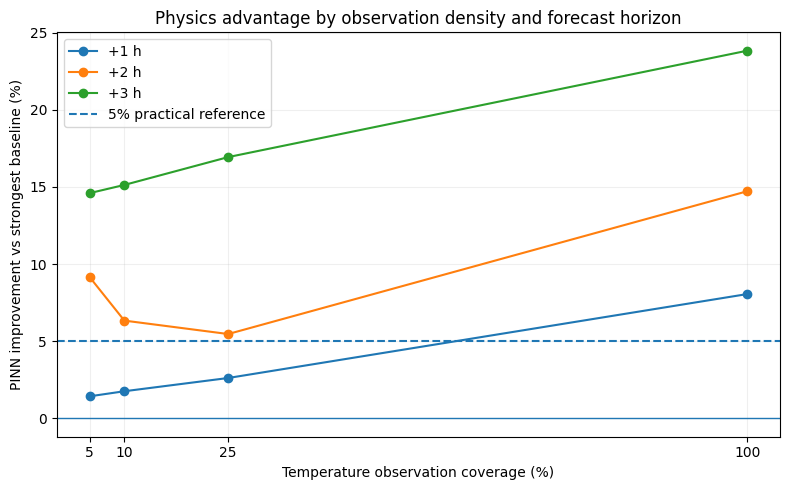

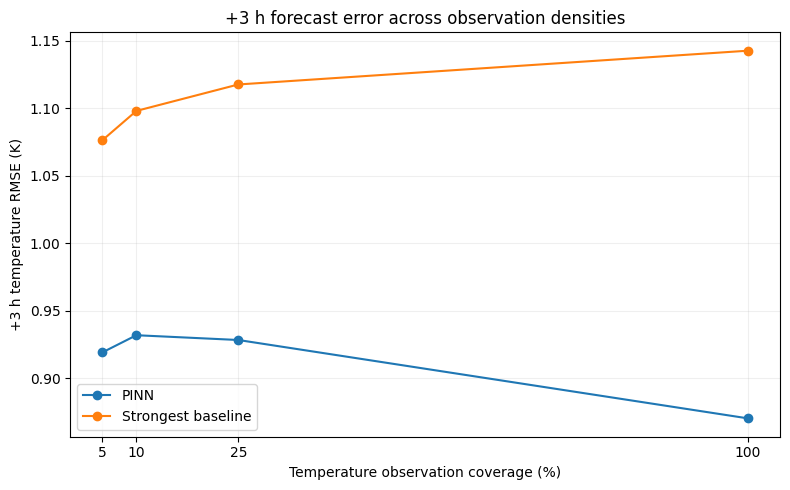


PINN improvement (%) matrix: rows=density, columns=lead hour


Lead_h,1,2,3
Observed_pct,,,
100.0,8.052832,14.716004,23.825732
25.0,2.614772,5.464090,16.930866
10.0,1.756306,6.334372,15.127110
5.0,1.429172,9.143005,14.597876


In [22]:

# 1) PINN improvement versus observation density, separately by lead.
fig, ax = plt.subplots(figsize=(8, 5))

for lead in range(1, FORECAST_HOURS+1):
    d = density_lead_summary[
        density_lead_summary["Lead_h"] == lead
    ].sort_values("Observed_pct")

    ax.plot(
        d["Observed_pct"],
        d["PINN_Improvement_pct"],
        marker="o",
        label=f"+{lead} h",
    )

ax.axhline(0.0, linewidth=1)
ax.axhline(
    MIN_MEAN_IMPROVEMENT_PCT,
    linestyle="--",
    label="5% practical reference",
)
ax.set_xlabel("Temperature observation coverage (%)")
ax.set_ylabel("PINN improvement vs strongest baseline (%)")
ax.set_title("Physics advantage by observation density and forecast horizon")
ax.set_xticks([5, 10, 25, 100])
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# 2) +3 h RMSE: PINN versus strongest baseline.
d3 = density_lead_summary[
    density_lead_summary["Lead_h"] == FORECAST_HOURS
].sort_values("Observed_pct")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    d3["Observed_pct"],
    d3["PINN_RMSE_K"],
    marker="o",
    label="PINN",
)
ax.plot(
    d3["Observed_pct"],
    d3["BestBaseline_RMSE_K"],
    marker="o",
    label="Strongest baseline",
)
ax.set_xlabel("Temperature observation coverage (%)")
ax.set_ylabel("+3 h temperature RMSE (K)")
ax.set_title("+3 h forecast error across observation densities")
ax.set_xticks([5, 10, 25, 100])
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# 3) Heatmap-style table for the central scientific result.
pivot = density_lead_summary.pivot(
    index="Observed_pct",
    columns="Lead_h",
    values="PINN_Improvement_pct",
).sort_index(ascending=False)

print("\nPINN improvement (%) matrix: rows=density, columns=lead hour")
display(pivot)



## How to interpret Phase 2B-2

This notebook is not designed to find a single “winning density.” It is designed to identify an **operating regime**.

The central scientific result is the matrix:

\[
\text{observation density} \times \text{forecast lead}.
\]

### Result patterns that would be meaningful

**Pattern A — robust physics advantage**
PINN remains better than the strongest baseline across most densities and the advantage grows with forecast lead.

This would support a strong practical statement: physics is useful for short-horizon thermal-state forecasting even when direct temperature observations are incomplete.

**Pattern B — density threshold**
PINN works at 25% and 10%, but deteriorates sharply at 5%.

This would identify a minimum thermal-observation density needed by this formulation.

**Pattern C — horizon-dependent regime**
PINN gives little or no advantage at +1 h, but a repeatable advantage at +2/+3 h over several densities.

This would support a more specific contribution: physics becomes valuable when temporal extrapolation becomes sufficiently difficult.

**Pattern D — no stable regime**
The sign of PINN improvement changes irregularly across densities and leads.

Then the present formulation is not robust enough for a deployment-oriented claim, even if individual runs are positive.

### What comes after this notebook

If a coherent operating regime appears, the next step should be **one final external/region robustness test**, not more tuning:

- same frozen formulation,
- one additional DigiCARES state/event,
- test only the regime identified here.

That would give the paper both:
1. a detailed Oklahoma operating-regime result, and
2. evidence that the result is not unique to one region.
